# Bayesian Statistics Explained for Marketers
## Companion Notebook

This notebook accompanies the article **"Bayesian Statistics Explained for Marketers"** on the [Marketing Data Science blog](https://blog.marketingdatascience.ai).

It walks through the Acme Shoes landing page example from the article:

- Acme Shoes redesigned its landing page.
- The historical conversion rate is **3.0%**.
- The new campaign produced **36 conversions from 1,000 visitors** (3.6% observed).
- The question: is the new page genuinely better, or did we just get lucky?

We answer that question two ways. First the Bayesian way, using a Beta-Binomial model with an exact closed-form solution. Then the Frequentist way, using a confidence interval and a hypothesis test. The point is not that one approach wins. The point is that they answer different questions.

Everything here runs top to bottom in Google Colab with no extra installs.

Author: Joe Domaleski, Marketing Data Science

## Setup

Standard scientific Python. Nothing exotic. We also define a clean, white-background plot style used for all figures in the article.

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Clean figure style: white background, no chartjunk
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#E0E0E0',
    'grid.linewidth': 0.6,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.frameon': False,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
})

# Color palette
BLUE = '#4285F4'    # posterior / Bayesian
GRAY = '#9E9E9E'    # prior / neutral
RED = '#EA4335'     # benchmark / emphasis
GREEN = '#34A853'   # shaded probability region
ORANGE = '#FBBC04'  # alternate prior

print('Setup complete.')

Setup complete.


## Step 1: The Scenario and the Data

One dataset drives the whole article. We state it once here and use it everywhere.

In [2]:
# Historical benchmark: the old landing page converted at 3.0%
benchmark = 0.03

# New campaign results
visitors = 1000
conversions = 36
observed_rate = conversions / visitors

print(f'Historical benchmark: {benchmark:.1%}')
print(f'New campaign: {conversions} conversions from {visitors} visitors')
print(f'Observed conversion rate: {observed_rate:.1%}')

Historical benchmark: 3.0%
New campaign: 36 conversions from 1000 visitors
Observed conversion rate: 3.6%


## Step 2: Building the Prior

A conversion rate is a number between 0 and 1. The **Beta distribution** is the natural way to describe beliefs about such a number. It takes two parameters, alpha and beta. A useful way to read them: alpha acts like a count of prior "successes" and beta like a count of prior "failures."

We use a **Beta(3, 97)** prior. Its mean is 3 / (3 + 97) = 3.0%, matching our historical rate. But it carries the weight of only about 100 pseudo-observations, so it is *weakly informative*. It says: "The rate is probably around 3%, but this is a redesigned page, so I am not very sure."

That humility is intentional. The page changed, so old certainty should not fully carry over.

In [3]:
# Weakly informative prior centered on the 3.0% historical rate
a_prior, b_prior = 3, 97
prior = stats.beta(a_prior, b_prior)

print(f'Prior: Beta({a_prior}, {b_prior})')
print(f'Prior mean: {prior.mean():.4f} ({prior.mean():.1%})')
print(f'Prior 95% interval: ({prior.ppf(0.025):.4f}, {prior.ppf(0.975):.4f})')

Prior: Beta(3, 97)
Prior mean: 0.0300 (3.0%)
Prior 95% interval: (0.0063, 0.0711)


## Step 3: The Posterior Update

Here is where the magic of **conjugate priors** shows up. When the prior is a Beta distribution and the data are binomial (a count of successes out of trials), the posterior is also a Beta distribution. No simulation, no MCMC, just arithmetic:

$$\text{Beta}(\alpha + \text{conversions},\ \beta + \text{non-conversions})$$

So our update is one line of code. Larger Bayesian models, like Marketing Mix Models, do not have this shortcut. That is where computational sampling methods such as MCMC come in. But the *logic* is identical to what happens in this cell.

In [4]:
# Conjugate update: Beta prior + binomial data = Beta posterior
a_post = a_prior + conversions
b_post = b_prior + (visitors - conversions)
posterior = stats.beta(a_post, b_post)

print(f'Posterior: Beta({a_post}, {b_post})')
print(f'Posterior mean: {posterior.mean():.4f} ({posterior.mean():.2%})')

Posterior: Beta(39, 1061)
Posterior mean: 0.0355 (3.55%)


## Step 4: Answering the Business Question

The question a marketer actually asks: **"What is the probability the new page genuinely performs better than our historical average?"**

The Bayesian framework answers it directly. We compute the probability that the true conversion rate exceeds 3.0% under the posterior distribution.

In [5]:
# Probability the true rate exceeds the 3.0% benchmark
prob_better = 1 - posterior.cdf(benchmark)

# 95% credible interval
ci_low, ci_high = posterior.ppf(0.025), posterior.ppf(0.975)

print(f'P(true rate > {benchmark:.1%}) = {prob_better:.4f} ({prob_better:.1%})')
print(f'95% credible interval: ({ci_low:.4f}, {ci_high:.4f})')
print(f'  In plain English: ({ci_low:.2%} to {ci_high:.2%})')

P(true rate > 3.0%) = 0.8365 (83.6%)
95% credible interval: (0.0254, 0.0472)
  In plain English: (2.54% to 4.72%)


There it is. Based on the available evidence, there is roughly an **84% probability** the new page genuinely performs better than the historical average.

The credible interval reads exactly the way people want intervals to read: given the model and the data, there is a 95% probability the true conversion rate falls inside it.

### Figure: The Posterior Distribution (article Figure 6, right panel)

The shaded region is the 84%.

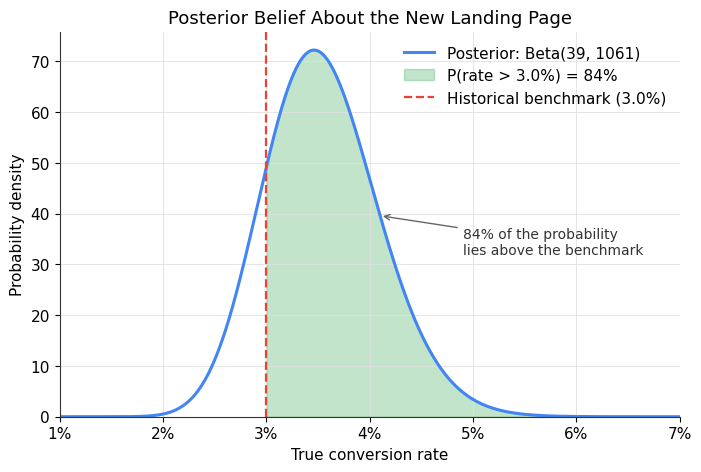

In [6]:
x = np.linspace(0.01, 0.07, 1000)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, posterior.pdf(x), color=BLUE, linewidth=2.2, label='Posterior: Beta(39, 1061)')

# Shade the region above the benchmark
x_shade = x[x >= benchmark]
ax.fill_between(x_shade, posterior.pdf(x_shade), color=GREEN, alpha=0.30,
                label=f'P(rate > 3.0%) = {prob_better:.0%}')

ax.axvline(benchmark, color=RED, linestyle='--', linewidth=1.6,
           label='Historical benchmark (3.0%)')

ax.annotate(f'{prob_better:.0%} of the probability\nlies above the benchmark',
            xy=(0.041, posterior.pdf(0.041)), xytext=(0.049, 32),
            fontsize=10, color='#333333',
            arrowprops=dict(arrowstyle='->', color='#666666', linewidth=1.0))

ax.set_xlabel('True conversion rate')
ax.set_ylabel('Probability density')
ax.set_title('Posterior Belief About the New Landing Page')
ax.set_xlim(0.01, 0.07)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(loc='upper right')

plt.savefig('figure6_posterior.png')
plt.show()

## Step 5: The Frequentist Analysis

Now the same data through the Frequentist lens. Two tools:

1. A **95% confidence interval** around the observed 3.6% rate (Wilson method).
2. A **one-sided exact binomial test** of the null hypothesis that the true rate is 3.0%, against the alternative that it is greater.

In [7]:
# One-sided exact binomial test against the 3.0% benchmark
test = stats.binomtest(conversions, visitors, p=benchmark, alternative='greater')
p_value = test.pvalue

# Standard two-sided 95% confidence interval (Wilson method)
test_two_sided = stats.binomtest(conversions, visitors, p=benchmark)
conf_int = test_two_sided.proportion_ci(confidence_level=0.95, method='wilson')

print(f'Observed rate: {observed_rate:.1%}')
print(f'95% confidence interval (Wilson): ({conf_int.low:.4f}, {conf_int.high:.4f})')
print(f'  In plain English: ({conf_int.low:.2%} to {conf_int.high:.2%})')
print(f'One-sided exact binomial test p-value: {p_value:.4f}')
print(f'Significant at 0.05? {"Yes" if p_value < 0.05 else "No"}')

Observed rate: 3.6%
95% confidence interval (Wilson): (0.0261, 0.0494)
  In plain English: (2.61% to 4.94%)
One-sided exact binomial test p-value: 0.1539
Significant at 0.05? No


The p-value is about **0.15**. Not significant at the usual 0.05 threshold. Notice the confidence interval contains 3.0%, which is another way of seeing the same thing.

So the Frequentist conclusion is: *"We cannot rule out that this is just chance."*

And the Bayesian conclusion is: *"There is an 84% probability the page is genuinely better."*

Same data. Both correct. Different questions.

## Step 6: Does the Prior Rig the Answer?

The most common objection to Bayesian methods: "You picked the prior, so you can get whatever answer you want."

Let's test that. We rerun the analysis with three very different priors:

- **Flat prior** Beta(1, 1): total ignorance, every rate equally likely.
- **Weak prior** Beta(3, 97): our choice, gently centered on 3.0%.
- **Skeptical prior** Beta(30, 970): strongly convinced the rate is 3.0%, worth about 1,000 pseudo-observations.

In [8]:
priors = {
    'Flat: Beta(1, 1)':         (1, 1,   GRAY),
    'Weak: Beta(3, 97)':        (3, 97,  BLUE),
    'Skeptical: Beta(30, 970)': (30, 970, ORANGE),
}

print(f'{"Prior":<28}{"Posterior mean":>16}{"P(rate > 3.0%)":>18}')
print('-' * 62)
results = {}
for name, (a, b, color) in priors.items():
    post = stats.beta(a + conversions, b + visitors - conversions)
    p_gt = 1 - post.cdf(benchmark)
    results[name] = (post, p_gt, color)
    print(f'{name:<28}{post.mean():>15.2%}{p_gt:>17.1%}')

Prior                         Posterior mean    P(rate > 3.0%)
--------------------------------------------------------------
Flat: Beta(1, 1)                      3.69%            88.3%
Weak: Beta(3, 97)                     3.55%            83.6%
Skeptical: Beta(30, 970)              3.30%            76.9%


All three priors land in the same neighborhood. Even the deliberately skeptical prior, which starts out ten times more confident than ours, still ends up favoring the new page. With 1,000 visitors of real data, the evidence does most of the talking. With 10,000 visitors, the three posteriors would be nearly indistinguishable.

Priors are not a way to rig the answer. They are a way to state your starting assumptions out loud, where everyone can inspect them and the data can correct them.

### Figure: Prior to Posterior, and Prior Sensitivity (article Figure 8)

Left panel: how the evidence moved our belief. Right panel: three different starting points converging.

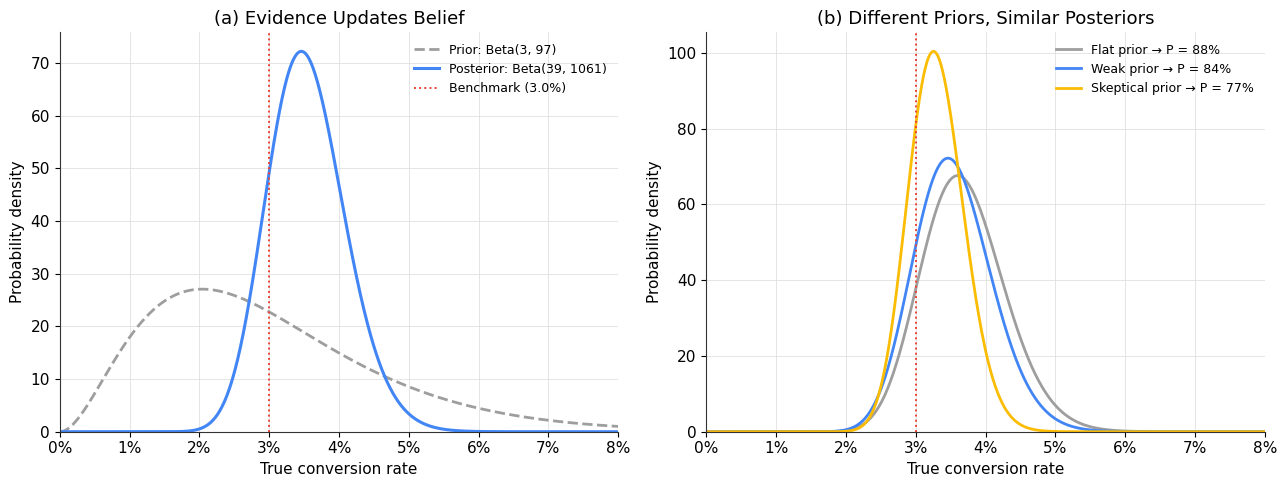

In [9]:
x_wide = np.linspace(0.0, 0.08, 1000)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: prior vs posterior
ax = axes[0]
ax.plot(x_wide, prior.pdf(x_wide), color=GRAY, linewidth=2.0, linestyle='--',
        label='Prior: Beta(3, 97)')
ax.plot(x_wide, posterior.pdf(x_wide), color=BLUE, linewidth=2.2,
        label='Posterior: Beta(39, 1061)')
ax.axvline(benchmark, color=RED, linestyle=':', linewidth=1.4,
           label='Benchmark (3.0%)')
ax.set_xlabel('True conversion rate')
ax.set_ylabel('Probability density')
ax.set_title('(a) Evidence Updates Belief')
ax.set_xlim(0.0, 0.08)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(loc='upper right', fontsize=9)

# Right panel: three priors converge
ax = axes[1]
for name, (post, p_gt, color) in results.items():
    ax.plot(x_wide, post.pdf(x_wide), color=color, linewidth=2.0,
            label=f'{name.split(":")[0]} prior → P = {p_gt:.0%}')
ax.axvline(benchmark, color=RED, linestyle=':', linewidth=1.4)
ax.set_xlabel('True conversion rate')
ax.set_ylabel('Probability density')
ax.set_title('(b) Different Priors, Similar Posteriors')
ax.set_xlim(0.0, 0.08)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('figure8_prior_posterior_sensitivity.png')
plt.show()

## Step 7: Credible Interval vs. Confidence Interval

Both intervals below come from the same Acme data, and numerically they nearly overlap. The difference is what they *mean*:

- **Confidence interval (Frequentist):** a statement about the *procedure*. If we repeated this campaign many times and built an interval each time, 95% of those intervals would capture the true rate. It says nothing direct about this one interval.
- **Credible interval (Bayesian):** a statement about the *parameter*. Given the model and the data, there is a 95% probability the true rate is inside this interval.

The credible interval is the sentence most people think they are saying when they report a confidence interval.

### Figure: Two Intervals, Two Meanings (article Figure 9)

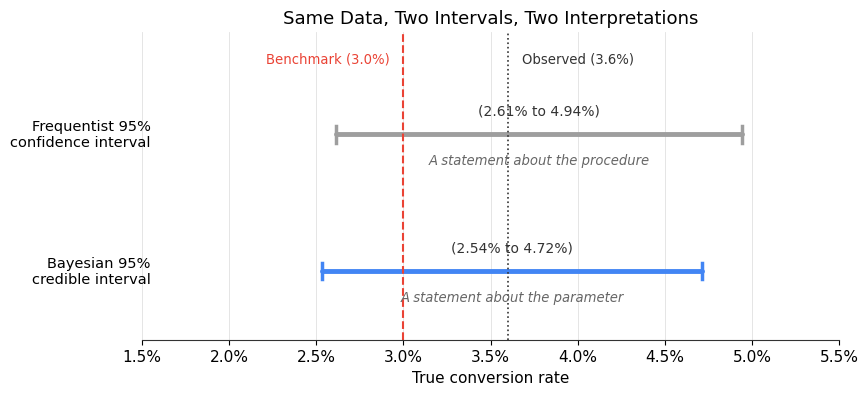

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))

intervals = [
    ('Frequentist 95%\nconfidence interval', conf_int.low, conf_int.high, GRAY,
     'A statement about the procedure'),
    ('Bayesian 95%\ncredible interval', ci_low, ci_high, BLUE,
     'A statement about the parameter'),
]

for i, (label, lo, hi, color, note) in enumerate(intervals):
    y = 1 - i
    ax.plot([lo, hi], [y, y], color=color, linewidth=3.5, solid_capstyle='round')
    ax.plot([lo, lo], [y - 0.06, y + 0.06], color=color, linewidth=2.5)
    ax.plot([hi, hi], [y - 0.06, y + 0.06], color=color, linewidth=2.5)
    mid = (lo + hi) / 2
    ax.text(mid, y + 0.14, f'({lo:.2%} to {hi:.2%})', ha='center',
            fontsize=10, color='#333333')
    ax.text(mid, y - 0.22, note, ha='center', fontsize=9.5,
            style='italic', color='#666666')
    ax.text(0.0155, y, label, ha='right', va='center', fontsize=10.5)

ax.axvline(benchmark, color=RED, linestyle='--', linewidth=1.5)
ax.text(benchmark - 0.0008, 1.52, 'Benchmark (3.0%)', ha='right', fontsize=9.5, color=RED)
ax.axvline(observed_rate, color='#333333', linestyle=':', linewidth=1.2)
ax.text(observed_rate + 0.0008, 1.52, 'Observed (3.6%)', ha='left', fontsize=9.5,
        color='#333333')

ax.set_xlim(0.015, 0.055)
ax.set_ylim(-0.5, 1.75)
ax.set_yticks([])
ax.grid(axis='y', visible=False)
ax.spines['left'].set_visible(False)
ax.set_xlabel('True conversion rate')
ax.set_title('Same Data, Two Intervals, Two Interpretations')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))

plt.savefig('figure9_intervals.png')
plt.show()

## Summary: The Numbers Quoted in the Article

Every statistic quoted in the article comes from this notebook. Here they are in one place.

In [11]:
print('ACME SHOES LANDING PAGE ANALYSIS: FINAL NUMBERS')
print('=' * 55)
print(f'Historical benchmark:        {benchmark:.1%}')
print(f'Campaign data:               {conversions} conversions / {visitors} visitors')
print(f'Observed rate:               {observed_rate:.1%}')
print()
print('FREQUENTIST')
print(f'  95% CI (Wilson):           {conf_int.low:.2%} to {conf_int.high:.2%}')
print(f'  One-sided exact p-value:   {p_value:.3f} (not significant at 0.05)')
print()
print('BAYESIAN')
print(f'  Prior:                     Beta({a_prior}, {b_prior}), mean {prior.mean():.1%}')
print(f'  Posterior:                 Beta({a_post}, {b_post}), mean {posterior.mean():.2%}')
print(f'  95% credible interval:     {ci_low:.2%} to {ci_high:.2%}')
print(f'  P(new page > benchmark):   {prob_better:.1%}')

ACME SHOES LANDING PAGE ANALYSIS: FINAL NUMBERS
Historical benchmark:        3.0%
Campaign data:               36 conversions / 1000 visitors
Observed rate:               3.6%

FREQUENTIST
  95% CI (Wilson):           2.61% to 4.94%
  One-sided exact p-value:   0.154 (not significant at 0.05)

BAYESIAN
  Prior:                     Beta(3, 97), mean 3.0%
  Posterior:                 Beta(39, 1061), mean 3.55%
  95% credible interval:     2.54% to 4.72%
  P(new page > benchmark):   83.6%


## Where to Go Next

This example had a closed-form solution because the Beta prior and binomial likelihood are conjugate. Real-world Bayesian models, like Google's Meridian for Marketing Mix Modeling, involve dozens of parameters and no closed-form shortcut. They rely on MCMC sampling to approximate the posterior. The logic, though, is exactly what you just ran: prior beliefs, observed evidence, updated beliefs.

Read the full article at [Marketing Data Science](https://blog.marketingdatascience.ai).

**References**

- Downey, Allen B. *Think Bayes: Bayesian Statistics in Python.* 2nd ed., O'Reilly Media, 2021.
- Virtanen, Pauli, et al. "SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python." *Nature Methods*, vol. 17, 2020, pp. 261-272.